# Segundo Exercício Usando o Keras

Nesse exercício, vocês devem preencher os campos de código deixados em branco para realizar as seguintes tarefas:

- Comparar redes neurais treinadas com diferentes algorítmos de treino

Vamos usar a mesma base de dados do primeiro exercício. Faça o download da base de dados [aqui](https://drive.google.com/file/d/1GfvKA0qznNVknghV4botnNxyH-KvODOC/view), e faça o upload dentro do Colab.

## Leitura dos dados

Criar uma função que irá ler e preprocessar a base de dados:

- Ler em uma data frame do pandas
- Transformar em vetores do numpy
- Aplicar preprocessamento
- Dividir em base de treino e teste

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

In [6]:
def prepara_base(nome_arquivo="housepricedata.csv", test_val_size=0.2):
  # Leitura do arquivo
  df = pd.read_csv(r"C:\Users\Acer\deep_learning_genai\introducao_redes_neurais\parte_1\housepricedata.csv")

  # Transforma em vetores numpy
  dataset = df.values

  # Divide em input e output
  X = dataset[:, 0:10]
  Y = dataset[:, 10]

  # Cria base de treino e teste
  X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_val_size)

  # Preprocessamento
  min_max_scaler = preprocessing.MinMaxScaler()
  X_train = min_max_scaler.fit_transform(X_train)
  X_test = min_max_scaler.transform(X_test)

  print(f"Dimensões de treino: {X_train.shape}")
  print(f"Dimensões de teste: {X_test.shape}")

  return X_train, Y_train, X_test, Y_test

In [7]:
X_train, Y_train, X_test, Y_test = prepara_base()

Dimensões de treino: (1168, 10)
Dimensões de teste: (292, 10)


## Criando e treinando a rede neural

In [8]:
import keras
from keras import layers

Vamos definir uma função que cria um modelo, assim podemos re-criar o modelo com a mesma arquitetura usando a função.

In [9]:
def cria_modelo():
    model = keras.models.Sequential([
        keras.Input(shape=(10, )),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1,activation='linear'),
    ])

    return model

### Comparando modelos

Vamos definir nossa métrica de sucesso como `accuracy` e treinar diferentes modelos. Vamos comparar o aprendizado e resultado final dos modelos. Para isso, vamos treinar os modelos em um `loop`.

> **Atenção: devido a natureza probabilística dos modelos, os seus resultados podem ser um pouco diferentes a cada vez que rodar o código**

In [11]:
algoritmos_treino = [
    "sgd",
    "rmsprop",
    "adam"
]

In [12]:
historico = {}
desempenho = {}
for opt_alg in algoritmos_treino:
    # Cria o modelo
    model = cria_modelo()

    # Compila com o algoritmo selecionado
    model.compile(
      optimizer=opt_alg,
      loss='binary_crossentropy',
      metrics=['accuracy']
    )

    # Treina o modelo
    hist = model.fit(X_train, Y_train, batch_size=64, epochs=20, verbose=0)

    historico[opt_alg] = hist.history
    avaliacao = model.evaluate(X_test, Y_test)
    desempenho[opt_alg] = {"loss": avaliacao[0], "accuracy": avaliacao[1]}

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 8.0590  
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9110 - loss: 0.3167  
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9007 - loss: 0.3420  


**Usando o matplotlib para visualizar a comparação:**

In [13]:
import matplotlib.pyplot as plt

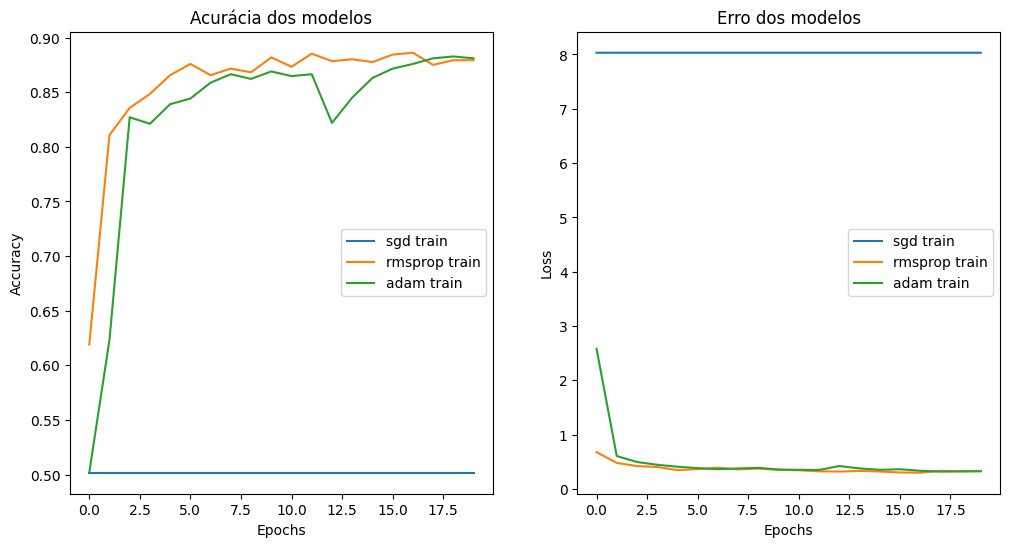

In [14]:
plt.figure(figsize=(12, 6))

# Evolução do desempenho (accuracy)
plt.subplot(1, 2, 1)
for name, history in historico.items():
    # Usa o valor de acurácia do histórico
    plt.plot(history['accuracy'], label=f'{name} train')

plt.title('Acurácia dos modelos')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Evolução do erro (loss)
plt.subplot(1, 2, 2)
for name, history in historico.items():
    # Usa o valor de perda do histórico
    plt.plot(history['loss'], label=f'{name} train')

plt.title('Erro dos modelos')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Sua análise: otmizador afeta a velocidade de aprendizado

**Comparando o desempenho na base de teste:**

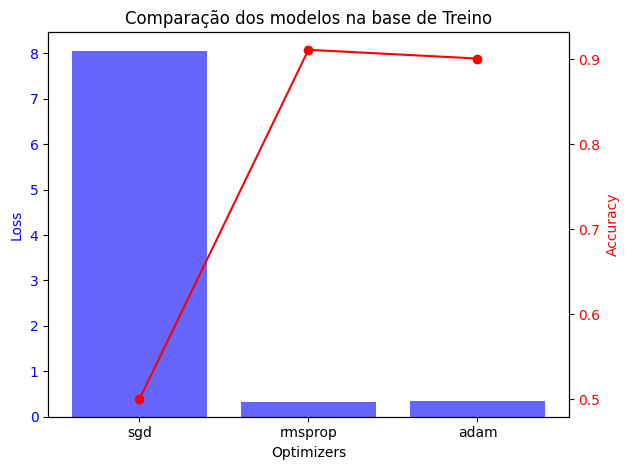

In [15]:
# Criando listas de perdas e desempenho
perdas = [desempenho[opt]["loss"] for opt in algoritmos_treino]
desempenhos = [desempenho[opt]["accuracy"] for opt in algoritmos_treino]

# Criando figara do matplotlib
fig, ax1 = plt.subplots()

# Perda (barplot)
ax1.bar(algoritmos_treino, perdas, color='b', alpha=0.6, label='Loss')
ax1.set_xlabel('Optimizers')
ax1.set_ylabel('Loss', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Colocando desempenho em um segundo eixo
ax2 = ax1.twinx()
ax2.plot(algoritmos_treino, desempenhos, color='r', marker='o', label='Accuracy')
ax2.set_ylabel('Accuracy', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Adding title and legend
plt.title('Comparação dos modelos na base de Treino')
fig.tight_layout()
plt.show()

Sua análise: otimizadores mostrando, a perda (loss) como barras e a acurácia como linha